# A quick demo for applying AGENT to a delayed transcription-splicing model

This tutorial uses the released two-species AGENT network and the bundled counts to infer four kinetic parameters. Run the cells in order with Julia 1.8.0, using `AGENT_analysis` as the notebook working directory. Install the project dependencies first with `julia --project=. -e 'using Pkg; Pkg.instantiate()'`; the current project expects `AGENT.jl` beside `AGENT_analysis`.


We illustrate the idea using a delayed transcription-splicing model. The full model is
$$
D_0 \xleftrightharpoons[\sigma_\text{off}]{\sigma_\text{on}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} S,
\qquad
S \xrightarrow{d} \varnothing .
$$
Here the gene switches between an inactive state $D_0$ and an active state $D_1$ with activation rate $\sigma_\text{on}$ for $D_0\to D_1$ and inactivation rate $\sigma_\text{off}$ for $D_1\to D_0$. When the gene is active, unspliced transcripts $U$ are produced at rate $\rho$. Each unspliced transcript is converted into a spliced transcript $S$ after a fixed processing delay $\tau$, and spliced transcripts are degraded with first-order rate $d$. The corresponding reduced model retains only the transcriptional dynamics of unspliced RNA,
$$
D_0 \xleftrightharpoons[\sigma_\text{off}]{\sigma_\text{on}} D_1, 
\qquad 
D_1 \xrightarrow{\rho} D_1+U,
\qquad
U \xRightarrow{\tau} \varnothing .
$$
The full model is then parametrized by $\varphi_\text{f}=(\sigma_\text{on},\sigma_\text{off},\rho,d)$, whereas the reduced model is parametrized by $\varphi_\text{r}=(\sigma_\text{on},\sigma_\text{off},\rho)$. The additional parameter in the full model is therefore the spliced-RNA degradation rate $d$. The goal of AGENT is to learn the map from the reduced PGF to the full PGF. Throughout this example, the delay is fixed at $\tau=1$. The diagram below summarizes the reduced-to-full PGF mapping and the agent-guided workflow.

![AGENT workflow](illustrate.png)

The released two-species network uses **8 inputs, 80 hidden units, and 49 outputs**, with `tanh` hidden activation and `sigmoid` output activation. The inputs are seven reduced PGF values plus the degradation rate $d$; the outputs are the full PGF on a $7\times7$ grid. Inference uses Float64. Input standardization is already folded into the released weights and must not be applied again.

The requested training recipe in `train_AGENT/2d/train_AGENT2d.jl` starts from random initialization and uses the 2,807 bundled training sets, with $n_z=7$ and $n_t=10^4$ SSA trajectories for the targets. It performs 2,000 Adam updates with
$$
\eta_t=0.03\times0.1^{(t-1)/1999},\qquad t=1,\ldots,2000,
$$
followed by 12,000 L-BFGS updates with history size $m=30$.

For a set of PGF collocation points $\mathbf{z_u}=(z_u^{(1)},\ldots,z_u^{(n_z)})^\top$ and $\mathbf{z_s}=(z_s^{(1)},\ldots,z_s^{(n_z)})^\top$ with $z_u^{(i)},z_s^{(i)}\in[0,1]$, we define the reduced-model PGF vector
$$
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r})
=
\left(
G(z_u^{(1)}|\varphi_\text{r}),
\ldots,
G(z_u^{(n_z)}|\varphi_\text{r})
\right)^\top
\in\mathbb{R}^{n_z}.
$$
The corresponding full-model PGF matrix is given by
$$
\mathbf{G}(\mathbf{z_u},\mathbf{z_s}|\varphi_\text{f})=\left[
G(z_u^{(i)},z_s^{(j)}|\varphi_\text{f})
\right]_{i,j=1}^{n_z}
\in\mathbb{R}^{n_z\times n_z}.
$$
AGENT is then represented as
$$
\text{NN}_\xi:
\left(
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r}),\,
\varphi_\text{f}\setminus\varphi_\text{r}
\right)
\mapsto
\text{vec}(\mathbf{G}(\mathbf{z_u},\mathbf{z_s}|\varphi_\text{f})^\top),
$$
where $G(z_u|\varphi_\text{r})$ and $G(z_u,z_s|\varphi_\text{f})$ are the probability generating function of reduced model and full model, respectively.

In the inference stage, the optimized network $\text{NN}_{\widehat{\xi}}$ is held fixed and used as a differentiable surrogate for the full-model PGF. 
Given experimental count pairs $\{(n_\text{u}^{(i)},n_\text{s}^{(i)})\}_{i=1}^{n_c}$, $n_c$ is the number of count pairs. We compute the empirical PGF matrix $\bar{\mathbf{G}}(\mathbf{z_u},\mathbf{z_s})$. The kinetic parameters of the full model are then inferred by solving
$$
\widehat{\varphi_\text{f}}
=
\arg\min_{\varphi_\text{f}\in\mathcal{D}_{\mathrm{f}}}\frac{1}{4}\mathbf{e}(\varphi_\text{f})^\top(\mathbf{W}\otimes \mathbf{W})\mathbf{e}(\varphi_\text{f})
$$
with
$$
\mathbf{e}(\varphi_\text{f})=\text{NN}_{\widehat{\xi}}
\left[
\mathbf{g}(\mathbf{z_u}|\varphi_\text{r}),
\varphi_\text{f}\setminus\varphi_\text{r}
\right]-\text{vec}\left[
\bar{\mathbf{G}}(\mathbf{z_u},\mathbf{z_s})\right].
$$
where $\mathbf{W}=\operatorname{diag}(w_1,\ldots,w_{N_y})$. Here is the example `Julia` code for parameter inference.

In [ ]:
# Activate the project from the notebook working directory.
using Pkg
notebook_dir = pwd()
isfile(joinpath(notebook_dir, "Project.toml")) && isfile(joinpath(notebook_dir, "Tutorials.ipynb")) ||
    error("Start this notebook with AGENT_analysis as its working directory.")
Pkg.activate(notebook_dir)
using Optim, Statistics, Plots, DelimitedFiles, LinearAlgebra
using FastGaussQuadrature, Flux, DataFrames, CSV
BLAS.set_num_threads(1)

  Activating project at `~/Documents/GitHub/AGENT_analysis`


In [2]:
# Define Reduced model PGF
function G_tele_delay(σon,σoff,ρ,τ,z)
    u1 = z-1
    r = 1-ρ*u1+σoff+σon
    θ = sqrt(Complex((ρ*u1-σoff-σon)^2+4*ρ*σon*u1))
    uz = (r+θ-1)/2
    uf = (r-θ-1)/2
    G1 = (uz*exp(-uf*τ)-uf*exp(-uz*τ))/θ + ρ*u1*σon*(exp(-uf*τ)-exp(-uz*τ))/(θ*(σoff+σon))
    return real(G1)
end

G_tele_delay (generic function with 1 method)

In [ ]:
# Map the reduced-model PGF and additional kinetic parameter to the full PGF.
function AGENT_forward(input, extra_parameters, params, reconstruct)
    network_input = vcat(input, extra_parameters)
    return Flux.sigmoid.(reconstruct(params)(network_input))
end

function AGENT_compute_full(ps, params, reconstruct)
    sigma_on, sigma_off, rho = ps[1:3]
    reduced_pgf = G_tele_delay.(sigma_on, sigma_off, rho, 1.0, z1)
    return vec(AGENT_forward(reduced_pgf, ps[4:end], params, reconstruct))
end

AGENT_compute_full (generic function with 1 method)

In [ ]:
# Preserve the released divergence, including the target-only constant.
function int_dist(ps, SSA_PGF, a, W, params, reconstruct)
    prediction = AGENT_compute_full(ps, params, reconstruct)
    dist = prediction.^(1+a) .- prediction.^a .* SSA_PGF .* (1+1/a) .+ SSA_PGF/a
    return sum(W .* dist)
end

int_dist (generic function with 1 method)

In [5]:
# Convert 2d distribution to PGF
function hist_gf2d(hist_data,z1,z2)
    Nx = size(hist_data,1)
    Ny = size(hist_data,2)
    z1_vec = [z1.^i for i = 0 : Nx-1]
    z2_vec = [z2.^i for i = 0 : Ny-1]
    z_mat = z1_vec*z2_vec'
    return sum(z_mat.*hist_data)
end

hist_gf2d (generic function with 1 method)

In [6]:
# Define Gaussian Quadrature points and corresponding weights
n = 7
a,b = [0,1]
interval_X, weights = gausslegendre(n)
x = ((b - a) .* interval_X .+ b .+ a) ./ 2
w = weights * (b - a) / 2

z1 = x
z2 = x

W = vec(w*w');

In [ ]:
# Released AGENT architecture: 8 -> 80 (tanh) -> 49 (sigmoid).
hidden_channels = 80
core = Flux.f64(Chain(Dense(length(z1)+1, hidden_channels, tanh),
                      Dense(hidden_channels, length(z1)*length(z2))))
# AGENT_forward applies sigmoid after this two-layer core.
_, re = Flux.destructure(core);

In [ ]:
# Load the published Float64 weights; standardization is already folded in.
weights_path = joinpath(notebook_dir, "parameters_trained", "params_trained2d.txt")
params = Float64.(CSV.read(weights_path, DataFrame).params)
@assert length(params) == 4689 && all(isfinite, params)
@assert eltype(re(params)[1].weight) == Float64

In [ ]:
# True parameters [sigma_on, sigma_off, rho, d]: [3.0634, 3.2981, 21.4090, 0.7231].
# The truth is not supplied to the optimizer.
counts_path = joinpath(notebook_dir, "dataset", "synthetic_data", "counts_example2d.txt")
SSA_counts = readdlm(counts_path)
U_sample = Int.(SSA_counts[:, 1])
S_sample = Int.(SSA_counts[:, 2])
Sample_size = length(U_sample)

# Convert counts to the empirical joint distribution.
joint_prob_matrix = zeros(Float64, maximum(U_sample)+1, maximum(S_sample)+1)
for (u, s) in zip(U_sample, S_sample)
    joint_prob_matrix[u+1, s+1] += 1
end
joint_prob_matrix ./= Sample_size

# z2 (spliced RNA) varies fastest in the released 2D output ordering.
SSA_PGF = vec(hist_gf2d(joint_prob_matrix, z1, z2)');

In [ ]:
# Infer positive kinetic parameters, starting from all ones.
init_ps = log.(ones(4))
timed_result = @timed Optim.optimize(
    q -> int_dist(exp.(q), SSA_PGF, 1.0, W, params, re), init_ps,
    Optim.Options(show_trace=false, g_tol=1e-11, iterations=1000))
opt = timed_result.value;

In [ ]:
# Compare the inferred physical parameters with the four-decimal truth.
inferred_params = exp.(Optim.minimizer(opt))
true_params = [3.0634, 3.2981, 21.4090, 0.7231]
relative_errors = abs.(inferred_params .- true_params) ./ true_params
mean_relative_error = mean(relative_errors)
println("Mean relative error: ", 100 * mean_relative_error, "%")
DataFrame(parameter=["sigma_on", "sigma_off", "rho", "d"],
          truth=true_params, inferred=inferred_params,
          relative_error_percent=100 .* relative_errors)

Mean relative error: 0.589232995056227%


Row,parameter,truth,inferred,relative_error_percent
,String,Float64,Float64,Float64
1,sigma_on,3.0634,3.07592,0.408851
2,sigma_off,3.2981,3.27692,0.642192
3,rho,21.409,21.4704,0.286826
4,d,0.7231,0.730469,1.01906


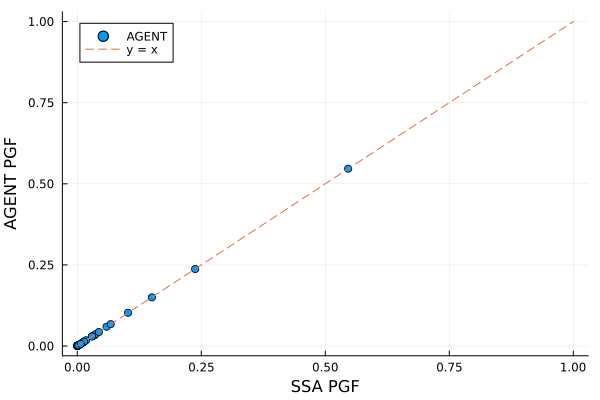

In [ ]:
# Plot the AGENT prediction against the empirical PGF.
inferred_PGF = AGENT_compute_full(inferred_params, params, re)
pgf_plot = scatter(SSA_PGF, inferred_PGF; xlabel="SSA PGF", ylabel="AGENT PGF", label="AGENT")
plot!(pgf_plot, [0, 1], [0, 1]; label="y = x", linestyle=:dash)